Install + Imports

In [1]:
!pip -q install scikit-learn pandas numpy matplotlib networkx

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.ensemble import IsolationForest
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_auc_score, roc_curve, auc

rng = np.random.default_rng(42)

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def clip01(x):
    return np.clip(x, 0, 1)

PLOT_DIR = "plots"
os.makedirs(PLOT_DIR, exist_ok=True)

def save_show(name):
    path = os.path.join(PLOT_DIR, name)
    plt.tight_layout()
    plt.savefig(path, dpi=200)
    plt.show()
    print("Saved:", path)

Simulate Dataset

In [2]:
def simulate_social_data(
    n_posts=120,
    n_users_organic=260,
    n_users_bots=60,
    n_rings=6,
    ring_size=12,
    days=7,
    p_comment=0.22,
    p_share=0.08
):
    start_ts = pd.Timestamp("2026-02-22 00:00:00")
    end_ts = start_ts + pd.Timedelta(days=days)

    post_ids = [f"p_{i:04d}" for i in range(n_posts)]
    post_publish = pd.to_datetime(
        rng.integers(start_ts.value//10**9, end_ts.value//10**9, size=n_posts),
        unit="s"
    )
    posts = pd.DataFrame({"post_id": post_ids, "publish_time": post_publish})

    organic_ids = [f"u_org_{i:04d}" for i in range(n_users_organic)]
    bot_ids = [f"u_bot_{i:04d}" for i in range(n_users_bots)]
    coord_ids = [f"u_cbot_{i:04d}" for i in range(n_rings * ring_size)]

    users = []
    for u in organic_ids:
        users.append((u, "organic", None))
    for u in bot_ids:
        users.append((u, "bot", None))
    for r in range(n_rings):
        for j in range(ring_size):
            users.append((coord_ids[r*ring_size + j], "coordinated_bot", f"ring_{r+1}"))

    users = pd.DataFrame(users, columns=["user_id", "label", "ring_id"])

    organic_templates = [
        "Loved this!", "Interesting point.", "Thanks for sharing!",
        "This is helpful.", "Great explanation.", "Nice post!",
        "Could you share more details?", "Really insightful."
    ]
    bot_templates = ["Nice!", "Great!", "Awesome!", "So good!", "Love it!", "Wow!", "Amazing!", "Cool!"]

    events = []
    event_id = 1

    def sample_event_type():
        r = rng.random()
        if r < p_share:
            return "share"
        elif r < p_share + p_comment:
            return "comment"
        else:
            return "like"

    def make_comment(label):
        if label == "organic":
            base = rng.choice(organic_templates)
            if rng.random() < 0.35:
                base += " " + rng.choice(["🙂", "!", "🔥", "👏", "✅", "👍"])
            if rng.random() < 0.25:
                base += " " + rng.choice(["I agree.", "Well said.", "Good to know.", "Makes sense."])
            return base
        else:
            base = rng.choice(bot_templates)
            if rng.random() < 0.7:
                base += "!"
            return base

    def random_timestamp():
        ts = rng.integers(start_ts.value//10**9, end_ts.value//10**9)
        return pd.to_datetime(ts, unit="s")

    # Organic
    for u in organic_ids:
        n_events = int(rng.integers(8, 60))
        for _ in range(n_events):
            pid = rng.choice(post_ids)
            etype = sample_event_type()
            ts = random_timestamp()
            comment = make_comment("organic") if etype == "comment" else None
            device = rng.choice(["android", "ios", "web"], p=[0.5, 0.25, 0.25])
            ip_hash = f"ip_{rng.integers(1, 700):03d}"
            events.append((event_id, u, pid, etype, ts, comment, device, ip_hash))
            event_id += 1

    # Random bots
    for u in bot_ids:
        n_events = int(rng.integers(50, 160))
        base_ts = random_timestamp()
        gap_sec = int(rng.choice([45, 60, 90, 120, 180]))
        for k in range(n_events):
            pid = rng.choice(post_ids)
            etype = rng.choice(["like", "comment"], p=[0.7, 0.3])
            ts = base_ts + pd.Timedelta(seconds=k*gap_sec + int(rng.normal(0, 3)))
            if ts > end_ts: break
            comment = make_comment("bot") if etype == "comment" else None
            device = rng.choice(["web", "android"], p=[0.8, 0.2])
            ip_hash = f"ip_{rng.integers(701, 950):03d}"
            events.append((event_id, u, pid, etype, ts, comment, device, ip_hash))
            event_id += 1

    # Coordinated rings
    for r in range(n_rings):
        ring_users = coord_ids[r*ring_size:(r+1)*ring_size]
        ring_posts = rng.choice(post_ids, size=int(rng.integers(8, 18)), replace=False)

        n_bursts = int(rng.integers(8, 14))  # slightly higher bursts -> stronger coordination
        burst_centers = [random_timestamp() for _ in range(n_bursts)]

        for center in burst_centers:
            pid = rng.choice(ring_posts)
            for u in ring_users:
                if rng.random() < 0.85:  # more members participate -> stronger signals
                    etype = rng.choice(["like", "comment", "share"], p=[0.6, 0.3, 0.1])
                    offset = int(rng.normal(0, 35))
                    ts = center + pd.Timedelta(seconds=offset)
                    comment = make_comment("bot") if etype == "comment" else None
                    device = rng.choice(["web", "android"], p=[0.85, 0.15])
                    ip_hash = f"ip_{rng.integers(951, 999):03d}"
                    events.append((event_id, u, pid, etype, ts, comment, device, ip_hash))
                    event_id += 1

        # filler
        for u in ring_users:
            n_events = int(rng.integers(30, 110))
            base_ts = random_timestamp()
            gap_sec = int(rng.choice([50, 70, 100]))
            for k in range(n_events):
                pid = rng.choice(ring_posts) if rng.random() < 0.25 else rng.choice(post_ids)
                etype = rng.choice(["like", "comment"], p=[0.75, 0.25])
                ts = base_ts + pd.Timedelta(seconds=k*gap_sec + int(rng.normal(0, 4)))
                if ts > end_ts: break
                comment = make_comment("bot") if etype == "comment" else None
                device = rng.choice(["web", "android"], p=[0.85, 0.15])
                ip_hash = f"ip_{rng.integers(951, 999):03d}"
                events.append((event_id, u, pid, etype, ts, comment, device, ip_hash))
                event_id += 1

    events = pd.DataFrame(events, columns=[
        "event_id","user_id","post_id","event_type","timestamp","comment_text","device","ip_hash"
    ])
    events["timestamp"] = pd.to_datetime(events["timestamp"])
    events = events.sort_values("timestamp").reset_index(drop=True)

    return users, posts, events

users_df, posts_df, events_df = simulate_social_data()
print(users_df["label"].value_counts())
print("Events:", len(events_df))
events_df.head()

label
organic            260
coordinated_bot     72
bot                 60
Name: count, dtype: int64
Events: 20973


,event_id,user_id,post_id,event_type,timestamp,comment_text,device,ip_hash
0,2452,u_org_0074,p_0062,share,2026-02-22 00:00:07,None,ios,ip_300
1,8133,u_org_0242,p_0106,share,2026-02-22 00:00:11,None,android,ip_652
2,3003,u_org_0090,p_0059,comment,2026-02-22 00:01:15,Great explanation.,web,ip_341
3,3168,u_org_0093,p_0017,like,2026-02-22 00:01:59,None,android,ip_568
4,7629,u_org_0224,p_0101,like,2026-02-22 00:02:38,None,android,ip_612


In [20]:
events_df.to_csv('events_df.csv', index=False)

User Behaviour Features

In [3]:
def build_user_features(events: pd.DataFrame) -> pd.DataFrame:
    e = events.copy().sort_values(["user_id", "timestamp"])
    e["prev_ts"] = e.groupby("user_id")["timestamp"].shift(1)
    e["gap_sec"] = (e["timestamp"] - e["prev_ts"]).dt.total_seconds()

    e["hour"] = e["timestamp"].dt.hour
    e["is_night"] = e["hour"].isin([0,1,2,3,4,5]).astype(int)

    g = e.groupby("user_id")
    feats = pd.DataFrame(index=g.size().index)
    feats["n_events"] = g.size().astype(int)

    feats["mean_gap_sec"] = g["gap_sec"].mean()
    feats["std_gap_sec"]  = g["gap_sec"].std()
    feats["median_gap_sec"] = g["gap_sec"].median()
    feats["cv_gap"] = feats["std_gap_sec"] / (feats["mean_gap_sec"] + 1e-9)
    feats["night_ratio"] = g["is_night"].mean()

    type_counts = pd.crosstab(e["user_id"], e["event_type"])
    for col in ["like","comment","share"]:
        if col not in type_counts.columns:
            type_counts[col] = 0
    type_counts = type_counts[["like","comment","share"]]

    feats["like_ratio"] = type_counts["like"] / (feats["n_events"] + 1e-9)
    feats["comment_ratio"] = type_counts["comment"] / (feats["n_events"] + 1e-9)
    feats["share_ratio"] = type_counts["share"] / (feats["n_events"] + 1e-9)

    unique_posts = g["post_id"].nunique()
    feats["unique_posts"] = unique_posts
    feats["repeat_post_ratio"] = 1 - (feats["unique_posts"] / (feats["n_events"] + 1e-9))

    e["hour_bucket"] = e["timestamp"].dt.floor("H")
    hourly = e.groupby(["user_id","hour_bucket"]).size().reset_index(name="events_per_hour")
    hg = hourly.groupby("user_id")["events_per_hour"]
    feats["hour_mean"] = hg.mean()
    feats["hour_max"] = hg.max()
    feats["spike_ratio"] = feats["hour_max"] / (feats["hour_mean"] + 1e-9)

    feats = feats.replace([np.inf, -np.inf], np.nan).fillna(0)
    return feats.reset_index()

user_feats = build_user_features(events_df)
user_feats.head()

/tmp/ipython-input-275/4160631556.py:33: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  e["hour_bucket"] = e["timestamp"].dt.floor("H")


,user_id,n_events,mean_gap_sec,std_gap_sec,median_gap_sec,cv_gap,night_ratio,like_ratio,comment_ratio,share_ratio,unique_posts,repeat_post_ratio,hour_mean,hour_max,spike_ratio
0,u_bot_0000,110,180.000000,2.834967,180.0,0.015750,0.000000,0.736364,0.263636,0.0,68,0.381818,18.333333,20,1.090909
1,u_bot_0001,133,179.992424,3.645548,180.0,0.020254,0.000000,0.736842,0.263158,0.0,84,0.368421,16.625000,20,1.203008
2,u_bot_0002,68,90.000000,4.274661,90.0,0.047496,0.117647,0.705882,0.294118,0.0,53,0.220588,22.666667,40,1.764706
3,u_bot_0003,130,180.038760,4.002739,180.0,0.022233,0.000000,0.669231,0.330769,0.0,75,0.423077,16.250000,20,1.230769
4,u_bot_0004,150,180.020134,3.737086,180.0,0.020759,0.000000,0.653333,0.346667,0.0,84,0.440000,18.750000,20,1.066667


Text Features (TF-IDF similarity + lexical diversity)

In [4]:
def build_text_features(events: pd.DataFrame, min_comments=3) -> pd.DataFrame:
    e = events[events["event_type"] == "comment"].copy()
    e["comment_text"] = e["comment_text"].fillna("").astype(str)

    all_comments = e["comment_text"].tolist()
    if len(all_comments) == 0:
        return pd.DataFrame(columns=["user_id","n_comments","text_sim_mean","unique_word_ratio_mean"])

    vect = TfidfVectorizer(ngram_range=(1,2), min_df=2, max_features=12000)
    X = vect.fit_transform(all_comments)

    e = e.reset_index(drop=True)
    e["row_idx"] = np.arange(len(e))

    rows_by_user = e.groupby("user_id")["row_idx"].apply(list)

    out = []
    for u, rows in rows_by_user.items():
        n = len(rows)
        if n < min_comments:
            out.append((u, n, 0.0, 0.0))
            continue

        Xu = X[rows]
        sim = cosine_similarity(Xu)
        iu = np.triu_indices_from(sim, k=1)
        sim_vals = sim[iu]
        sim_mean = float(sim_vals.mean()) if sim_vals.size > 0 else 0.0

        texts = e.loc[rows, "comment_text"].tolist()
        ratios = []
        for t in texts:
            toks = [w for w in t.lower().split() if w.strip()]
            ratios.append(len(set(toks))/len(toks) if len(toks) else 0.0)

        uniq_ratio_mean = float(np.mean(ratios)) if ratios else 0.0
        out.append((u, n, sim_mean, uniq_ratio_mean))

    return pd.DataFrame(out, columns=["user_id","n_comments","text_sim_mean","unique_word_ratio_mean"])

text_feats = build_text_features(events_df)
text_feats.head()

,user_id,n_comments,text_sim_mean,unique_word_ratio_mean
0,u_bot_0000,29,0.137931,1.0
1,u_bot_0001,35,0.114286,1.0
2,u_bot_0002,20,0.094737,1.0
3,u_bot_0003,43,0.119601,1.0
4,u_bot_0004,52,0.134238,1.0


Coordination Features (Upgraded thresholds)

In [5]:
def build_coordination_features(events: pd.DataFrame, window_sec=120, min_hits=4):
    e = events.copy().sort_values("timestamp")
    e["ts_sec"] = e["timestamp"].astype("int64") // 10**9

    pairs = {}
    for pid, grp in e.groupby("post_id"):
        arr = grp[["user_id","ts_sec"]].values
        for i in range(len(arr)):
            u_i, t_i = arr[i]
            j = i + 1
            while j < len(arr) and (arr[j][1] - t_i) <= window_sec:
                u_j = arr[j][0]
                if u_i != u_j:
                    a, b = (u_i, u_j) if u_i < u_j else (u_j, u_i)
                    pairs[(a,b)] = pairs.get((a,b), 0) + 1
                j += 1

    coord_score = {}
    for (a,b), c in pairs.items():
        coord_score[a] = coord_score.get(a, 0) + c
        coord_score[b] = coord_score.get(b, 0) + c

    coord_df = pd.DataFrame({"user_id": list(coord_score.keys()),
                             "coengagement_hits": list(coord_score.values())})

    edges = [(a,b,c) for (a,b), c in pairs.items() if c >= min_hits]
    return coord_df, edges

coord_feats, edges = build_coordination_features(events_df, window_sec=120, min_hits=4)
print("Edges for strong coordination:", len(edges))
coord_feats.head()

Edges for strong coordination: 404


,user_id,coengagement_hits
0,u_cbot_0003,75
1,u_cbot_0009,95
2,u_cbot_0006,81
3,u_cbot_0002,77
4,u_cbot_0000,95


Merge all + Build X_scaled correctly

In [6]:
df = user_feats.merge(text_feats, on="user_id", how="left").merge(coord_feats, on="user_id", how="left")
df[["n_comments","text_sim_mean","unique_word_ratio_mean","coengagement_hits"]] = (
    df[["n_comments","text_sim_mean","unique_word_ratio_mean","coengagement_hits"]].fillna(0)
)
df = df.merge(users_df[["user_id","label","ring_id"]], on="user_id", how="left")

feature_cols = [
    "n_events","mean_gap_sec","std_gap_sec","median_gap_sec","cv_gap",
    "night_ratio","like_ratio","comment_ratio","share_ratio",
    "unique_posts","repeat_post_ratio",
    "hour_mean","hour_max","spike_ratio",
    "n_comments","text_sim_mean","unique_word_ratio_mean",
    "coengagement_hits"
]

X = df[feature_cols].replace([np.inf, -np.inf], 0).fillna(0).values
X_scaled = StandardScaler().fit_transform(X)

df.head()

,user_id,n_events,mean_gap_sec,std_gap_sec,median_gap_sec,cv_gap,night_ratio,like_ratio,comment_ratio,share_ratio,...,repeat_post_ratio,hour_mean,hour_max,spike_ratio,n_comments,text_sim_mean,unique_word_ratio_mean,coengagement_hits,label,ring_id
0,u_bot_0000,110,180.000000,2.834967,180.0,0.015750,0.000000,0.736364,0.263636,0.0,...,0.381818,18.333333,20,1.090909,29.0,0.137931,1.0,0.0,bot,None
1,u_bot_0001,133,179.992424,3.645548,180.0,0.020254,0.000000,0.736842,0.263158,0.0,...,0.368421,16.625000,20,1.203008,35.0,0.114286,1.0,10.0,bot,None
2,u_bot_0002,68,90.000000,4.274661,90.0,0.047496,0.117647,0.705882,0.294118,0.0,...,0.220588,22.666667,40,1.764706,20.0,0.094737,1.0,6.0,bot,None
3,u_bot_0003,130,180.038760,4.002739,180.0,0.022233,0.000000,0.669231,0.330769,0.0,...,0.423077,16.250000,20,1.230769,43.0,0.119601,1.0,10.0,bot,None
4,u_bot_0004,150,180.020134,3.737086,180.0,0.020759,0.000000,0.653333,0.346667,0.0,...,0.440000,18.750000,20,1.066667,52.0,0.134238,1.0,7.0,bot,None


Isolation Forest

In [7]:
iso = IsolationForest(n_estimators=250, contamination=0.18, random_state=42)
iso.fit(X_scaled)

normal_score = iso.score_samples(X_scaled)
anomaly_raw = -normal_score
df["anomaly_score"] = (anomaly_raw - anomaly_raw.min()) / (anomaly_raw.max() - anomaly_raw.min() + 1e-9)

df[["user_id","anomaly_score","label"]].sort_values("anomaly_score", ascending=False).head(10)

,user_id,anomaly_score,label
317,u_org_0185,1.000000,organic
65,u_cbot_0005,0.958727,coordinated_bot
149,u_org_0017,0.899391,organic
283,u_org_0151,0.872547,organic
280,u_org_0148,0.861230,organic
9,u_bot_0009,0.828666,bot
59,u_bot_0059,0.826587,bot
43,u_bot_0043,0.818004,bot
319,u_org_0187,0.785789,organic
195,u_org_0063,0.767400,organic


DBSCAN + create in_coord_cluster

In [8]:
coord_model_cols = ["coengagement_hits","cv_gap","text_sim_mean","repeat_post_ratio","spike_ratio"]
Xc_scaled = StandardScaler().fit_transform(df[coord_model_cols].values)

db = DBSCAN(eps=0.85, min_samples=5)
df["coord_cluster"] = db.fit_predict(Xc_scaled)
df["in_coord_cluster"] = (df["coord_cluster"] != -1).astype(int)

df[["user_id","coord_cluster","coengagement_hits","label"]].sort_values("coengagement_hits", ascending=False).head(12)

,user_id,coord_cluster,coengagement_hits,label
118,u_cbot_0058,1,133.0,coordinated_bot
120,u_cbot_0060,1,121.0,coordinated_bot
117,u_cbot_0057,1,121.0,coordinated_bot
108,u_cbot_0048,1,120.0,coordinated_bot
116,u_cbot_0056,1,119.0,coordinated_bot
111,u_cbot_0051,1,117.0,coordinated_bot
115,u_cbot_0055,1,117.0,coordinated_bot
73,u_cbot_0013,1,114.0,coordinated_bot
109,u_cbot_0049,1,114.0,coordinated_bot
126,u_cbot_0066,1,113.0,coordinated_bot


Final Scoring (Bot probability + Authenticity)

In [9]:
text_susp = clip01(0.75*df["text_sim_mean"].values + 0.25*(1 - df["unique_word_ratio_mean"].values))
coord_susp = clip01((df["coengagement_hits"].values / (df["coengagement_hits"].max() + 1e-9))*0.7
                    + 0.3*df["in_coord_cluster"].values)

w1, w2, w3 = 1.3, 1.0, 1.2
logit = (w1*df["anomaly_score"].values + w2*text_susp + w3*coord_susp) - 1.2

df["bot_probability"] = sigmoid(logit)
df["authenticity_score"] = np.round(100*(1 - df["bot_probability"]), 2)

def cat(p):
    if p >= 0.75: return "Likely Bot"
    if p >= 0.45: return "Suspicious"
    return "Authentic"
df["risk_category"] = df["bot_probability"].apply(cat)

df[["user_id","authenticity_score","bot_probability","risk_category","label"]].sort_values("bot_probability", ascending=False).head(15)

,user_id,authenticity_score,bot_probability,risk_category,label
118,u_cbot_0058,29.15,0.708508,Suspicious,coordinated_bot
122,u_cbot_0062,29.34,0.706590,Suspicious,coordinated_bot
111,u_cbot_0051,30.41,0.695900,Suspicious,coordinated_bot
116,u_cbot_0056,30.47,0.695292,Suspicious,coordinated_bot
108,u_cbot_0048,31.59,0.684054,Suspicious,coordinated_bot
115,u_cbot_0055,32.04,0.679616,Suspicious,coordinated_bot
65,u_cbot_0005,32.33,0.676657,Suspicious,coordinated_bot
130,u_cbot_0070,32.55,0.674473,Suspicious,coordinated_bot
86,u_cbot_0026,33.00,0.670049,Suspicious,coordinated_bot
120,u_cbot_0060,33.00,0.670028,Suspicious,coordinated_bot


Explanation Engine

In [10]:
def explain_user(row):
    reasons = []

    if row["cv_gap"] < 0.12 and row["n_events"] > 25:
        reasons.append(f"Very low timing variance (CV={row['cv_gap']:.2f}) suggests automation.")

    if row["spike_ratio"] > 3.5 and row["hour_max"] >= 8:
        reasons.append(f"Engagement bursts (spike_ratio={row['spike_ratio']:.2f}, max/hour={int(row['hour_max'])}).")

    if row["repeat_post_ratio"] > 0.65:
        reasons.append(f"Repeated engagement on limited posts (repeat_ratio={row['repeat_post_ratio']:.2f}).")

    if row["n_comments"] >= 3 and row["text_sim_mean"] > 0.65:
        reasons.append(f"Repetitive comments (avg similarity={row['text_sim_mean']:.2f}).")

    if row["n_comments"] >= 3 and row["unique_word_ratio_mean"] < 0.55:
        reasons.append(f"Low lexical diversity (unique_word_ratio={row['unique_word_ratio_mean']:.2f}).")

    if row["in_coord_cluster"] == 1 and row["coengagement_hits"] > 0:
        reasons.append(f"Coordinated co-engagement detected (hits={int(row['coengagement_hits'])}).")

    if row["night_ratio"] > 0.45 and row["n_events"] > 30:
        reasons.append(f"High night activity (night_ratio={row['night_ratio']:.2f}).")

    if not reasons:
        reasons = ["No strong anomalies detected; behaviour appears organic."]
    return reasons[:3]

df["top_anomalies"] = df.apply(explain_user, axis=1)
df[["user_id","bot_probability","risk_category","top_anomalies","label"]].sort_values("bot_probability", ascending=False).head(8)

,user_id,bot_probability,risk_category,top_anomalies,label
118,u_cbot_0058,0.708508,Suspicious,"[Engagement bursts (spike_ratio=7.12, max/hour...",coordinated_bot
122,u_cbot_0062,0.706590,Suspicious,"[Engagement bursts (spike_ratio=9.00, max/hour...",coordinated_bot
111,u_cbot_0051,0.695900,Suspicious,"[Engagement bursts (spike_ratio=6.37, max/hour...",coordinated_bot
116,u_cbot_0056,0.695292,Suspicious,"[Engagement bursts (spike_ratio=7.17, max/hour...",coordinated_bot
108,u_cbot_0048,0.684054,Suspicious,"[Engagement bursts (spike_ratio=6.94, max/hour...",coordinated_bot
115,u_cbot_0055,0.679616,Suspicious,"[Engagement bursts (spike_ratio=7.88, max/hour...",coordinated_bot
65,u_cbot_0005,0.676657,Suspicious,"[Engagement bursts (spike_ratio=5.26, max/hour...",coordinated_bot
130,u_cbot_0070,0.674473,Suspicious,"[Engagement bursts (spike_ratio=8.66, max/hour...",coordinated_bot


Evaluation

In [11]:
y_true = (df["label"] != "organic").astype(int).values
y_pred = (df["bot_probability"].values >= 0.5).astype(int)

print(classification_report(y_true, y_pred, digits=3))
print("ROC-AUC:", round(roc_auc_score(y_true, df["bot_probability"].values), 4))

              precision    recall  f1-score   support

           0      0.859     0.865     0.862       260
           1      0.731     0.720     0.725       132

    accuracy                          0.816       392
   macro avg      0.795     0.793     0.794       392
weighted avg      0.816     0.816     0.816       392

ROC-AUC: 0.9261


TOP-10 Table + Save

In [12]:
top10 = df.sort_values("bot_probability", ascending=False).head(10)[
    ["user_id","bot_probability","authenticity_score","risk_category",
     "coengagement_hits","cv_gap","text_sim_mean","spike_ratio","top_anomalies","label"]
].copy()

top10.to_csv("top10_suspicious_users.csv", index=False)
print("Saved: top10_suspicious_users.csv")
top10

Saved: top10_suspicious_users.csv


,user_id,bot_probability,authenticity_score,risk_category,coengagement_hits,cv_gap,text_sim_mean,spike_ratio,top_anomalies,label
118,u_cbot_0058,0.708508,29.15,Suspicious,133.0,4.142698,0.160000,7.125000,"[Engagement bursts (spike_ratio=7.12, max/hour...",coordinated_bot
122,u_cbot_0062,0.706590,29.34,Suspicious,108.0,2.064923,0.133333,9.000000,"[Engagement bursts (spike_ratio=9.00, max/hour...",coordinated_bot
111,u_cbot_0051,0.695900,30.41,Suspicious,117.0,4.140338,0.129412,6.375000,"[Engagement bursts (spike_ratio=6.37, max/hour...",coordinated_bot
116,u_cbot_0056,0.695292,30.47,Suspicious,119.0,4.387968,0.122507,7.172414,"[Engagement bursts (spike_ratio=7.17, max/hour...",coordinated_bot
108,u_cbot_0048,0.684054,31.59,Suspicious,120.0,4.165007,0.125000,6.941176,"[Engagement bursts (spike_ratio=6.94, max/hour...",coordinated_bot
115,u_cbot_0055,0.679616,32.04,Suspicious,117.0,4.106964,0.114625,7.878788,"[Engagement bursts (spike_ratio=7.88, max/hour...",coordinated_bot
65,u_cbot_0005,0.676657,32.33,Suspicious,70.0,1.351621,0.000000,5.263158,"[Engagement bursts (spike_ratio=5.26, max/hour...",coordinated_bot
130,u_cbot_0070,0.674473,32.55,Suspicious,104.0,2.655614,0.128205,8.659574,"[Engagement bursts (spike_ratio=8.66, max/hour...",coordinated_bot
86,u_cbot_0026,0.670049,33.00,Suspicious,94.0,3.353454,0.108466,5.707317,"[Engagement bursts (spike_ratio=5.71, max/hour...",coordinated_bot
120,u_cbot_0060,0.670028,33.00,Suspicious,121.0,3.091602,0.142857,6.300000,"[Engagement bursts (spike_ratio=6.30, max/hour...",coordinated_bot


Case-study timeline plots (Top 3 users)

Case-study users: ['u_cbot_0058', 'u_cbot_0062', 'u_cbot_0051']


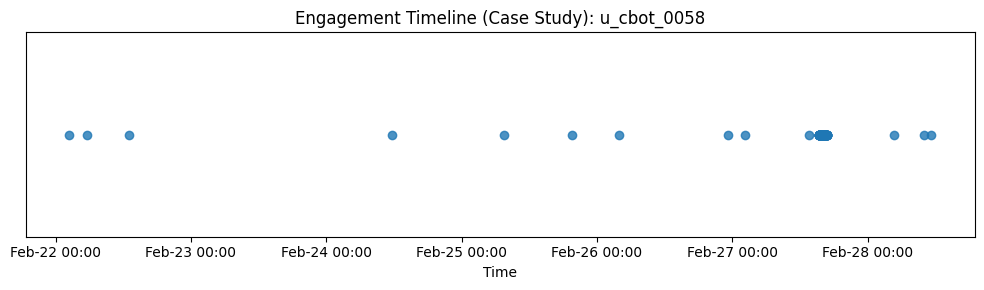

Saved: plots/case_timeline_u_cbot_0058.png


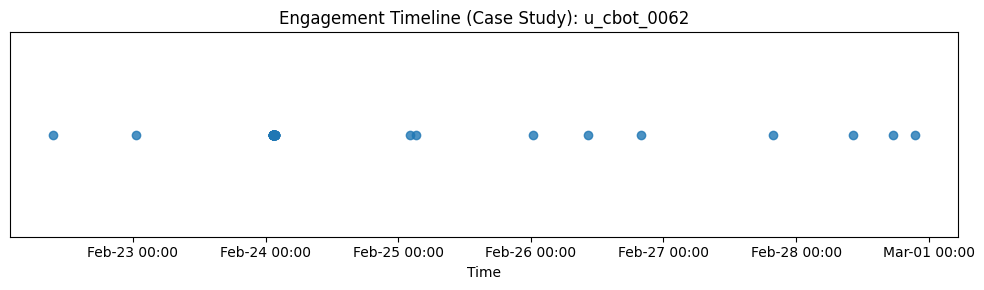

Saved: plots/case_timeline_u_cbot_0062.png


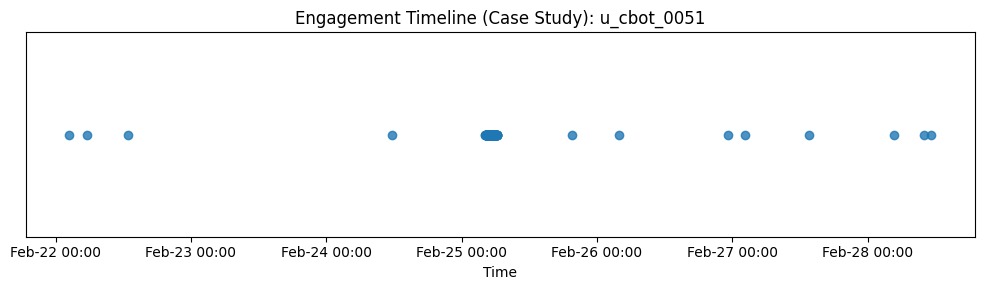

Saved: plots/case_timeline_u_cbot_0051.png


In [13]:
import matplotlib.dates as mdates

top_users = df.sort_values("bot_probability", ascending=False)["user_id"].head(3).tolist()
print("Case-study users:", top_users)

for u in top_users:
    u_events = events_df[events_df["user_id"] == u].copy().sort_values("timestamp")

    plt.figure(figsize=(10, 3))
    plt.scatter(u_events["timestamp"], np.ones(len(u_events)), alpha=0.8)
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b-%d %H:%M'))
    plt.gca().yaxis.set_visible(False)
    plt.title(f"Engagement Timeline (Case Study): {u}")
    plt.xlabel("Time")
    save_show(f"case_timeline_{u}.png")

## Engagement Timeline – Case Study (Individual Users)

This timeline visualizes the engagement activity of selected highly suspicious users over time. Instead of exhibiting continuous or randomly spaced activity like organic users, these accounts show engagement in short, dense bursts, often occurring at similar times across multiple days. Such bursty and repetitive patterns are indicative of automated or coordinated scheduling rather than natural human behaviour. The temporal regularity and clustering strongly suggest participation in coordinated bot campaigns.

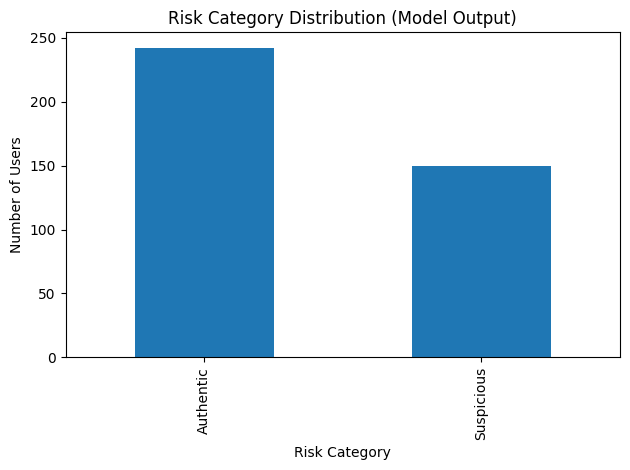

Saved: plots/W1_risk_category_distribution.png


In [14]:


# 1) Risk Category Distribution
plt.figure()
df["risk_category"].value_counts().plot(kind="bar")
plt.title("Risk Category Distribution (Model Output)")
plt.xlabel("Risk Category")
plt.ylabel("Number of Users")
save_show("W1_risk_category_distribution.png")



## Risk Category Distribution (Model Output)

This bar chart shows the distribution of users across different risk categories generated by the proposed system. The majority of users are classified as **Authentic**, while a substantial portion is labeled **Suspicious**. This demonstrates that the model adopts a conservative and realistic approach, flagging borderline cases without aggressively labeling users as bots. Such behaviour-driven caution is essential in real-world social media platforms to minimize false positives.

<Figure size 640x480 with 0 Axes>

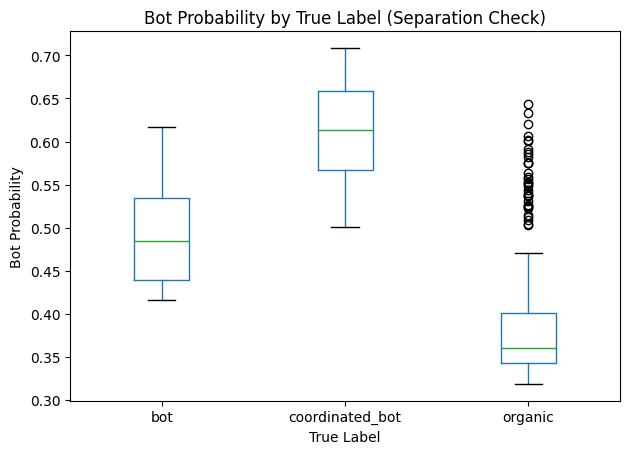

Saved: plots/W2_botprob_by_label_boxplot.png


In [15]:

# 2) Bot Probability by True Label
plt.figure()
df.boxplot(column="bot_probability", by="label", grid=False)
plt.title("Bot Probability by True Label (Separation Check)")
plt.suptitle("")
plt.xlabel("True Label")
plt.ylabel("Bot Probability")
save_show("W2_botprob_by_label_boxplot.png")




## Bot Probability by True Label (Separation Check)

This boxplot compares bot probability scores across different ground-truth user categories. Organic users consistently show lower bot probabilities, while bot and coordinated bot accounts display significantly higher values. Coordinated bots have the highest median scores, reflecting the model’s ability to detect group-level manipulation behaviour. The clear separation between categories validates the discriminative power of the proposed scoring mechanism.

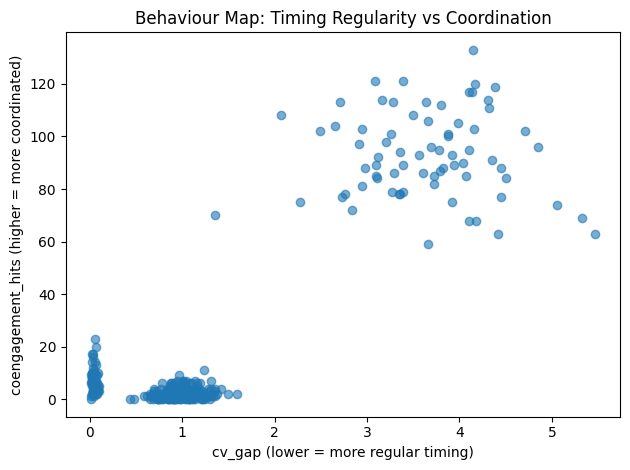

Saved: plots/W3_behaviour_map_cv_vs_coord.png


In [16]:
# 3) Behaviour Map: Timing Regularity vs Coordination
plt.figure()
plt.scatter(df["cv_gap"], df["coengagement_hits"], alpha=0.6)
plt.title("Behaviour Map: Timing Regularity vs Coordination")
plt.xlabel("cv_gap (lower = more regular timing)")
plt.ylabel("coengagement_hits (higher = more coordinated)")
save_show("W3_behaviour_map_cv_vs_coord.png")



## Behaviour Map: Timing Regularity vs Coordination

This scatter plot jointly visualizes timing regularity and coordination intensity. Organic users cluster in regions with moderate timing variability and minimal coordination. Random bots exhibit highly regular timing but limited coordination, while coordinated bots occupy regions with high co-engagement hits and irregular burst patterns. The clear spatial separation of these groups highlights how behavioural signals effectively distinguish different forms of malicious activity.

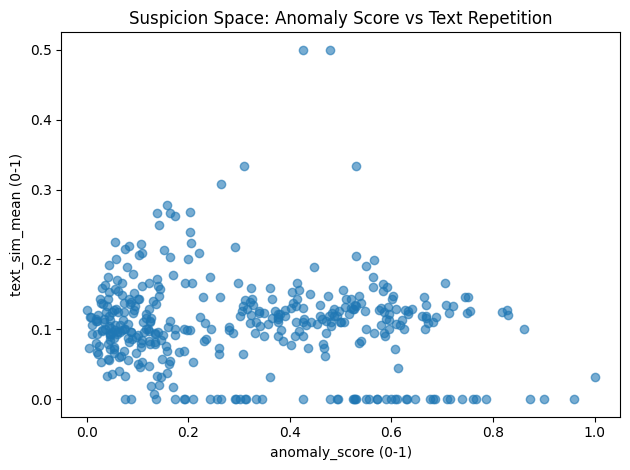

Saved: plots/W4_anomaly_vs_text.png


In [17]:

# 4) Suspicion Space: Anomaly Score vs Text Repetition
plt.figure()
plt.scatter(df["anomaly_score"], df["text_sim_mean"], alpha=0.6)
plt.title("Suspicion Space: Anomaly Score vs Text Repetition")
plt.xlabel("anomaly_score (0-1)")
plt.ylabel("text_sim_mean (0-1)")
save_show("W4_anomaly_vs_text.png")




## Suspicion Space: Anomaly Score vs Text Repetition

This plot maps users into a two-dimensional suspicion space based on behavioural anomaly scores and linguistic repetition. Organic users concentrate in the low-anomaly, low-repetition region, whereas automated accounts exhibit higher anomaly scores and repeated textual patterns. Users appearing in the upper-right region demonstrate both abnormal behaviour and templated language usage, making them strong candidates for automated or coordinated manipulation.

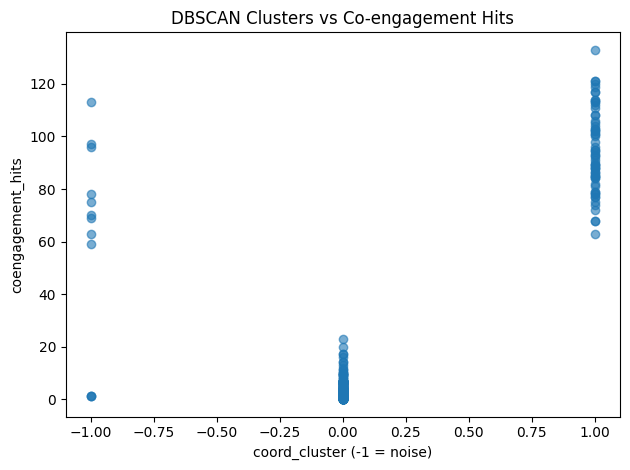

Saved: plots/W5_dbscan_clusters_vs_hits.png


In [18]:
# 5) DBSCAN Coordination Clusters vs Co-engagement Hits
plt.figure()
plt.scatter(df["coord_cluster"], df["coengagement_hits"], alpha=0.6)
plt.title("DBSCAN Clusters vs Co-engagement Hits")
plt.xlabel("coord_cluster (-1 = noise)")
plt.ylabel("coengagement_hits")
save_show("W5_dbscan_clusters_vs_hits.png")



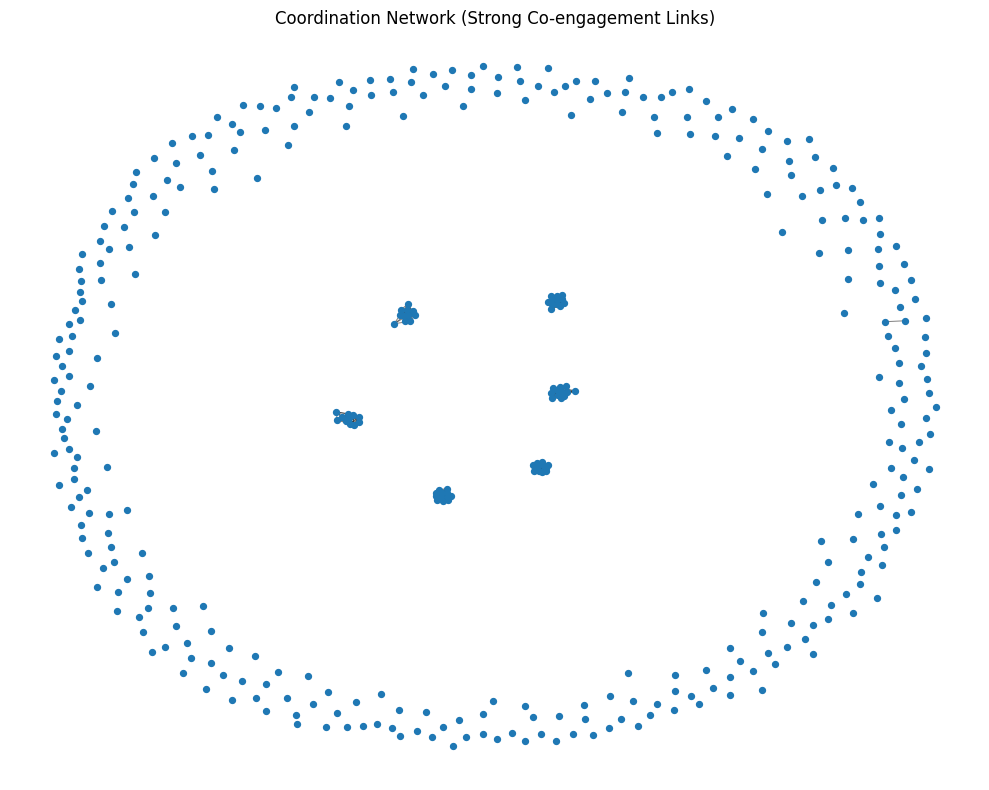

Saved: plots/W6_coordination_network.png


In [19]:

# 6) Coordination Network Graph (WOW)
G = nx.Graph()
G.add_nodes_from(df["user_id"].tolist())

edges_sorted = sorted(edges, key=lambda x: x[2], reverse=True)

TOP_EDGES = min(350, len(edges_sorted))  # safe cap
for a, b, c in edges_sorted[:TOP_EDGES]:
    G.add_edge(a, b, weight=c)

plt.figure(figsize=(10, 8))
pos = nx.spring_layout(G, seed=42, k=0.15)
nx.draw_networkx_nodes(G, pos, node_size=18)
nx.draw_networkx_edges(G, pos, width=0.7, alpha=0.5)

plt.title("Coordination Network (Strong Co-engagement Links)")
plt.axis("off")
save_show("W6_coordination_network.png")

## Coordination Network Graph (Strong Co-engagement Links)

The coordination network graph visualizes strong co-engagement relationships between users. Dense clusters represent coordinated bot rings, where multiple accounts repeatedly interact with the same content within short time windows. In contrast, organic users appear largely isolated. This network-level view reveals collective manipulation patterns that cannot be identified through individual behavioural features alone.

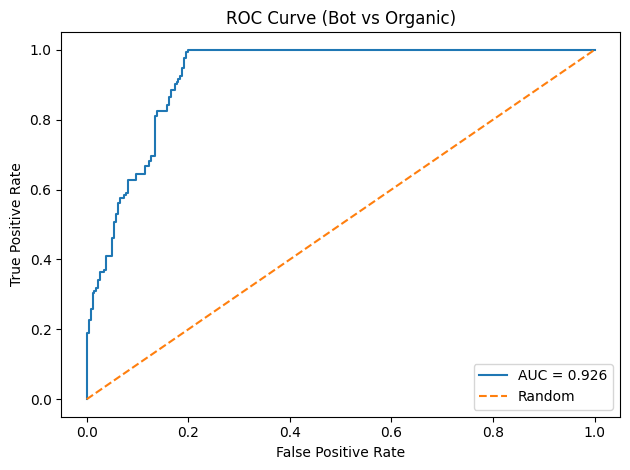

Saved: plots/roc_curve.png


In [22]:
from sklearn.metrics import roc_curve, auc

y_true = (df["label"] != "organic").astype(int).values
y_score = df["bot_probability"].values

fpr, tpr, _ = roc_curve(y_true, y_score)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], linestyle="--", label="Random")
plt.title("ROC Curve (Bot vs Organic)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
save_show("roc_curve.png")

These results demonstrate that our system captures both individual automation and coordinated manipulation using interpretable behavioural signals.